# Import Required Libraries

### Description

In this step, we import all the necessary libraries required for the anomaly detection system.

These libraries help us perform:

* **Numerical computations** (`NumPy`)
* **Data manipulation and analysis** (`Pandas`)
* **Data visualization** (`Matplotlib`, `Seaborn`)
* **Data preprocessing and evaluation** (`Scikit-learn`)
* **Deep learning model development** (`TensorFlow/Keras`)
* **File handling and model saving** (`pickle`, `os`)
* **Warning suppression** to keep the output clean.

These tools together enable building and evaluating a **deep learning model for detecting anomalies in nuclear power plant equipment sensor data**.


In [3]:
# Import NumPy for numerical operations and array manipulation
import numpy as np

# Import Pandas for data loading, cleaning, and analysis
import pandas as pd

# Import Matplotlib for plotting graphs and visualizing data
import matplotlib.pyplot as plt

# Import MinMaxScaler to normalize data values between 0 and 1
from sklearn.preprocessing import MinMaxScaler

# Import evaluation metrics to measure anomaly detection performance
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, accuracy_score

# Import TensorFlow framework used to build deep learning models
import tensorflow as tf

# Import Sequential model which allows stacking neural network layers sequentially
from tensorflow.keras.models import Sequential

# Import deep learning layers used for feature extraction and sequence learning
from tensorflow.keras.layers import Conv1D, LSTM, RepeatVector, Dense

# Import Adam optimizer to update model weights during training
from tensorflow.keras.optimizers import Adam

# Import Seaborn for advanced statistical visualization such as heatmaps
import seaborn as sns

# Import warnings module to control warning messages
import warnings

# Import pickle for saving and loading trained models
import pickle

# Import os module for interacting with the operating system (file paths, directories)
import os

# Suppress warning messages to keep notebook output clean
warnings.filterwarnings('ignore')

## Step 1: Load the Dataset

### Description

In this step, we load the dataset that contains the **sensor readings from the nuclear power plant equipment**.
The dataset is stored in a **CSV (Comma-Separated Values) file**, which is a common format for storing structured data.

Using **Pandas**, we read the dataset into a **DataFrame**, which allows us to easily manipulate, analyze, and preprocess the data.

After loading the dataset, we also print its **shape** to understand:

* The **number of rows** (data samples or time steps)
* The **number of columns** (sensor features)

This helps verify that the dataset has been loaded correctly.


In [4]:
# STEP 1: LOAD DATASET

# Print a step indicator so users know which stage of the pipeline is running
print("\n[STEP 1] Loading dataset...")

# Read the CSV file containing the sensor data into a Pandas DataFrame
df = pd.read_csv("SWaT_modified_8_features_dataset.csv")

# Display the shape of the dataset (rows, columns)
# Rows represent observations and columns represent features/sensors
print(f"Dataset shape: {df.shape}")
print(f"Sample of the data: {df.head()}")


[STEP 1] Loading dataset...
Dataset shape: (10048, 10)
Sample of the data:              Timestamp  Coolant_Flow_Rate  Reactor_Pressure  \
0  22/12/2015 10:00:00           2.427057          522.8467   
1  22/12/2015 10:00:01           2.446274          522.8860   
2  22/12/2015 10:00:02           2.489191          522.8467   
3  22/12/2015 10:00:03           2.534350          522.9645   
4  22/12/2015 10:00:04           2.569260          523.4748   

   Core_Pressure_Differential  Neutron_Flux  Reactor_Core_Temperature  \
0                    19.74838      2.206835                  956.1651   
1                    19.74838      2.208244                  956.1651   
2                    19.69076      2.208628                  956.4855   
3                    19.69076      2.208628                  956.8060   
4                    19.69076      2.208628                  957.0864   

   Electrical_Power_Output  Radiation_Level  Safety_Monitoring_Parameter  \
0                 1.713517    

## Step 2: Drop Timestamp and Normalize Sensor Data

### Description

In this step, we prepare the dataset for training the anomaly detection model.

First, we **clean and standardize the label column** to ensure that all labels follow a consistent format. Since datasets sometimes contain inconsistent formatting (such as uppercase letters or extra spaces), we convert all labels to **lowercase** and remove unnecessary whitespace.

Next, we **convert the categorical labels into numerical values**. Machine learning models require numerical inputs, so we map:

* **Normal → 0**
* **Attack / Anomaly / Abnormal → 1**

This converts the problem into a **binary classification task**, where:

* `0` represents **normal operation**
* `1` represents **anomalous behavior**

After that, we separate the dataset into:

* **Features (X)** → sensor readings
* **Labels (y)** → anomaly indicators

The **timestamp column is excluded** because it does not provide useful numerical information for the neural network.

Finally, we **normalize the sensor values** using **MinMaxScaler**, which scales all features into the range **0 to 1**.
Normalization helps neural networks train faster and improves model stability because all features operate on the same scale.


In [5]:
# STEP 2: PARSE TIMESTAMP AND NORMALIZE

# Print step header to indicate preprocessing stage
print("\n[STEP 2] Parsing timestamp and normalizing sensors...")

# Clean the 'Label' column:
# - Convert values to string
# - Remove extra spaces
# - Convert to lowercase for consistency
df['Label'] = df['Label'].astype(str).str.strip().str.lower()

# Convert categorical labels into numerical values
# Normal operation -> 0
# Attack/Anomaly/Abnormal -> 1
df['Label'] = df['Label'].map({
    'normal': 0,
    'attack': 1,
    'anomaly': 1,
    'abnormal': 1
})

# Display the distribution of labels
# This helps check if the dataset is balanced or imbalanced
print("\nLabel distribution:")
print(df['Label'].value_counts())

# Extract feature values
# Skip Timestamp (col 0) and Label (last col) → extracts 7 sensor features
# NOTE: Coolant_Flow_Rate is col 0 after Timestamp and is NOT included
X = df.iloc[:, 1:-1].values

# Extract labels from the last column
y = df.iloc[:, -1].values.astype(int)

# Initialize MinMaxScaler to normalize feature values between 0 and 1
scaler = MinMaxScaler()

# Fit the scaler to the feature data and transform it
X_scaled = scaler.fit_transform(X)

# Print the shape of the scaled feature matrix
# This shows number of samples and number of sensor features
print(f"X shape: {X_scaled.shape}")


[STEP 2] Parsing timestamp and normalizing sensors...

Label distribution:
Label
0    6048
1    4000
Name: count, dtype: int64
X shape: (10048, 8)


## Step 3 : Create Sliding Windows for Time-Series Sequences

### Description

In time-series anomaly detection, models like **LSTM and CNN-LSTM** do not look at individual sensor readings independently. Instead, they analyze **patterns across a sequence of time steps**.

To achieve this, we create **sliding windows** (also called **time sequences**) from the normalized sensor data.

A **window size of 50** means:

* Each training sample contains **50 consecutive time steps of sensor readings**.
* The model learns how the system behaves over those 50 steps.

The sliding window moves **one step at a time**, creating overlapping sequences:

Example:

| Window | Data Used   |
| ------ | ----------- |
| 1      | rows 0 → 49 |
| 2      | rows 1 → 50 |
| 3      | rows 2 → 51 |

For each window:

* **X_windows** stores the sequence of sensor values.
* **y_windows** stores the **label corresponding to the next time step**.

This approach helps the model learn **temporal dependencies and abnormal patterns over time**.

### Expected Output Example

```
Creating sliding windows (window_size=50)...
X_windows shape: (49950, 50, 8)
```

### Explanation of Shape

| Dimension | Meaning                          |
| --------- | -------------------------------- |
| **49950** | Number of sliding window samples |
| **50**    | Time steps in each sequence      |
| **8**     | Number of sensor features        |

So each training example looks like:

```
[50 time steps × 8 sensors]
```

This structure is ideal for **CNN-LSTM models**, which can learn both:

* **Spatial patterns across sensors (CNN)**
* **Temporal dependencies across time (LSTM)**

In [7]:
# STEP 3 : CREATE SLIDING WINDOWS

# Print step header
print("\n[STEP 3] Creating sliding windows (window_size=50)...")

# Define the number of time steps in each sequence
window_size = 50

# Lists to store generated sequences and their corresponding labels
X_windows = []
y_windows = []

# Loop through the dataset to create sliding windows
for i in range(len(X_scaled) - window_size):

    # Extract a sequence of 50 consecutive time steps
    X_windows.append(X_scaled[i:i + window_size])

    # Assign the label of the next time step after the window
    # This represents whether the sequence leads to a normal or anomalous state
    y_windows.append(y[i + window_size])

# Convert lists into NumPy arrays for efficient computation
X_windows = np.array(X_windows)
y_windows = np.array(y_windows)

# Print the shape of the generated sequences
print(f"X_windows shape: {X_windows.shape}")


[STEP 3] Creating sliding windows (window_size=50)...
X_windows shape: (9998, 50, 8)


## Step 4 : Select Normal Data for Training

### Description

In **autoencoder-based anomaly detection**, the model is trained **only on normal system behavior**.

The idea is that the model learns how **normal equipment operation looks over time**. When the model later encounters abnormal data (attacks or faults), it will **fail to reconstruct the input accurately**, producing a **high reconstruction error**, which indicates an anomaly.

In this step:

1. We **identify indices where the label is 0 (normal)**.
2. We **select only those windows for training**.
3. These normal sequences are stored in **`X_train`**.

Training only on normal data helps the model learn the **baseline operating behavior of the nuclear power plant sensors**.

### Example Output

```
[STEP 4] Separating normal data for training...
Training samples: 47000
```

This means the model will **only learn from normal operating conditions**.


In [8]:
# STEP 4 : SEPERATING NORMAL ONLY

# Print step message
print("\n[STEP 4] Separating normal data for training...")

# Find indices where the label indicates normal behavior (0)
normal_idx = np.where(y_windows == 0)[0]

# Select only normal sequences for training
X_train = X_windows[normal_idx]

# Display number of training samples
print(f"Training samples: {len(X_train)}")


[STEP 4] Separating normal data for training...
Training samples: 5998


# Step 5 : Build the Conv1D–LSTM Autoencoder Model

### Description

In this step, we build a **Conv1D-LSTM Autoencoder** to learn patterns in the time-series sensor data.

This architecture combines **two powerful deep learning techniques**:

### 1️⃣ Conv1D Layer

* Extracts **local patterns from sensor signals**
* Captures relationships between **neighboring time steps**

### 2️⃣ LSTM Layer

* Learns **temporal dependencies** in sequential data
* Remembers long-term patterns across time

### 3️⃣ RepeatVector

* Expands the encoded representation back into a sequence

### 4️⃣ Decoder LSTM

* Reconstructs the original sequence from the compressed representation

### 5️⃣ Dense Layer

* Produces the final reconstructed sensor values

Since this is an **autoencoder**, the model tries to **reconstruct the input sequence**.
If the reconstruction error is high, the sequence is likely **anomalous**.

### Model Architecture Summary (Concept)

```
Input Sequence (50 × 8 sensors)
        │
        ▼
Conv1D Feature Extraction
        │
        ▼
LSTM Encoder
        │
        ▼
Latent Representation
        │
        ▼
RepeatVector
        │
        ▼
LSTM Decoder
        │
        ▼
Dense Layer
        │
        ▼
Reconstructed Sequence
```

In [9]:
# STEP 5 : BUILD MODEL

# Print step message
print("\n[STEP 7] Building Conv1D-LSTM Autoencoder...")

# Get number of sensor features from the training data
n_features = X_train.shape[2]

# Build sequential neural network model
model = Sequential([

    # Conv1D layer extracts spatial patterns from time-series data
    Conv1D(
        filters=32,                 # Number of filters (feature detectors)
        kernel_size=3,              # Size of the convolution window
        padding='same',             # Keep output size same as input
        activation='relu',          # Activation function
        input_shape=(window_size, n_features)  # Input sequence shape
    ),

    # LSTM encoder compresses sequence into latent representation
    LSTM(
        64,                         # Number of memory units
        activation='relu',
        return_sequences=False      # Output a single encoded vector
    ),

    # Repeat the encoded vector to match the sequence length
    RepeatVector(window_size),

    # LSTM decoder reconstructs the time-series sequence
    LSTM(
        64,
        activation='relu',
        return_sequences=True       # Return reconstructed sequence
    ),

    # Dense layer reconstructs original sensor feature values
    Dense(
        n_features,
        activation='linear'         # Linear activation for regression output
    )
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),  # Adam optimizer for training
    loss='mse'                            # Mean Squared Error for reconstruction
)

# Display model architecture
model.summary()


[STEP 7] Building Conv1D-LSTM Autoencoder...
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 50, 32)            800       
                                                                 
 lstm (LSTM)                 (None, 64)                24832     
                                                                 
 repeat_vector (RepeatVector  (None, 50, 64)           0         
 )                                                               
                                                                 
 lstm_1 (LSTM)               (None, 50, 64)            33024     
                                                                 
 dense (Dense)               (None, 50, 8)             520       
                                                                 
Total params: 59,176
Trainable params: 59,176
Non-trainable params: 0
______

## Step 6 : Train the Autoencoder Model

### Description

In this step, we train the **Conv1D–LSTM Autoencoder** using the **normal operating data** prepared earlier.

Since this is an **autoencoder**, the model learns by trying to **reconstruct its own input**. Therefore:

* The **input data** is `X_train`
* The **target output** is also `X_train`

During training, the model learns the **normal patterns of sensor behavior**. Later, when abnormal data is given to the model, it will struggle to reconstruct it correctly, resulting in a **higher reconstruction error**, which indicates an anomaly.

Key parameters used during training:

* **epochs = 50** → the number of times the model sees the entire dataset.
* **batch_size = 32** → number of samples processed before updating model weights.
* **validation_split = 0.1** → 10% of training data is used to validate model performance during training.
* **verbose = 1** → displays training progress in the console.

The training results are stored in the **`history` object**, which contains the training and validation loss values that can later be used for **visualizing learning performance**.

### What Happens During Training

For each training step:

1. The model **receives a sequence of sensor readings**.
2. The **encoder compresses the sequence into a latent representation**.
3. The **decoder reconstructs the sequence**.
4. The **Mean Squared Error (MSE)** between input and output is calculated.
5. The optimizer (**Adam**) updates model weights to **minimize reconstruction error**.


In [10]:
# STEP 6 : TRAIN

# Print step message to indicate training phase
print("\n[STEP 8] Training the autoencoder...")

# Train the autoencoder model
history = model.fit(
    
    X_train,        # Input data (normal sequences)
    X_train,        # Target output (same as input for autoencoder)
    
    epochs=30,      # Number of training iterations over the entire dataset
    
    batch_size=32,  # Number of samples processed in each training step
    
    validation_split=0.1,  # Use 10% of training data for validation
    
    verbose=1       # Display training progress
)


[STEP 8] Training the autoencoder...
Epoch 1/30
169/169 [==============================] - 8s 41ms/step - loss: 0.0204 - val_loss: 0.0016
Epoch 2/30
169/169 [==============================] - 7s 44ms/step - loss: 6.4324e-04 - val_loss: 7.3131e-04
Epoch 3/30
169/169 [==============================] - 7s 44ms/step - loss: 4.6350e-04 - val_loss: 4.8734e-04
Epoch 4/30
169/169 [==============================] - 7s 42ms/step - loss: 3.8209e-04 - val_loss: 4.3872e-04
Epoch 5/30
169/169 [==============================] - 7s 42ms/step - loss: 3.2801e-04 - val_loss: 6.2647e-04
Epoch 6/30
169/169 [==============================] - 7s 43ms/step - loss: 2.9371e-04 - val_loss: 3.1344e-04
Epoch 7/30
169/169 [==============================] - 7s 44ms/step - loss: 2.5698e-04 - val_loss: 4.8670e-04
Epoch 8/30
169/169 [==============================] - 7s 43ms/step - loss: 2.3388e-04 - val_loss: 4.4822e-04
Epoch 9/30
169/169 [==============================] - 7s 44ms/step - loss: 2.1494e-04 - val_loss: 

## Step 7 : Calculate Reconstruction Errors

### Description

After training the autoencoder, the next step is to **measure how well the model reconstructs the input sequences**.

Since the autoencoder was trained only on **normal system behavior**, it should reconstruct normal sequences **very accurately**. However, when the model encounters **abnormal or anomalous patterns**, the reconstruction will be poor, resulting in a **higher reconstruction error**.

In this step:

1. The trained model **predicts (reconstructs) the training sequences**.
2. We calculate the **difference between the original sequences and the reconstructed sequences**.
3. The **Mean Squared Error (MSE)** is used to quantify the reconstruction error.

The reconstruction error is computed across:

* **Time steps**
* **Sensor features**

This produces **one error value per sequence**, which will later be used to **determine the anomaly detection threshold**.

### What This Code Does

| Operation                  | Purpose                                                    |
| -------------------------- | ---------------------------------------------------------- |
| `model.predict(X_train)`   | Reconstructs input sequences using the trained autoencoder |
| `X_train - X_train_pred`   | Calculates reconstruction difference                       |
| `np.square()`              | Squares the differences to penalize larger errors          |
| `np.mean(..., axis=(1,2))` | Averages errors across time steps and features             |


In [8]:
# STEP 7 : CALCULATE ERRORS

# Print step message to indicate reconstruction error calculation
print("\n[STEP 9] Calculating reconstruction errors...")

# Use the trained autoencoder to reconstruct the training sequences
X_train_pred = model.predict(X_train, verbose=0)

# Calculate reconstruction error using Mean Squared Error (MSE)
# Step 1: Subtract reconstructed data from original data
# Step 2: Square the difference
# Step 3: Take the mean across time steps and sensor features
train_errors = np.mean(np.square(X_train - X_train_pred), axis=(1, 2))


[STEP 9] Calculating reconstruction errors...


## Step 8 : Set Anomaly Detection Threshold

### Description

After calculating the **reconstruction errors** for the normal training data, the next step is to determine a **threshold value** that separates **normal behavior from anomalies**.

Since the model was trained only on **normal sequences**, their reconstruction errors should be **small and concentrated around a mean value**.

To define a safe boundary, we use a common statistical rule:

[
\text{Threshold} = \text{Mean Error} + 3 \times \text{Standard Deviation}
]

This method is based on the **3-sigma rule** in statistics. It assumes that most normal data falls within **three standard deviations of the mean**. Any sequence with an error **above this threshold** is likely to be an **anomaly**.

This threshold will later be used to **classify sequences as normal or anomalous**.

### What This Code Does

| Operation               | Purpose                                        |
| ----------------------- | ---------------------------------------------- |
| `np.mean(train_errors)` | Calculates average reconstruction error        |
| `np.std(train_errors)`  | Measures variation of errors                   |
| `mean + 3 × std`        | Defines boundary separating normal vs abnormal |
| `:.6f`                  | Formats output to 6 decimal places             |

---

### Example Output

```
[STEP 10] Setting threshold...
Threshold: 0.003742
```

### Interpretation

| Error Value           | Meaning                    |
| --------------------- | -------------------------- |
| **Error ≤ Threshold** | Normal system behavior     |
| **Error > Threshold** | Potential anomaly detected |


In [9]:
# STEP 8 : SET THRESHOLD

# Print step message to indicate threshold calculation
print("\n[STEP 8] Setting threshold...")

# Calculate anomaly detection threshold
# Mean reconstruction error + 3 times the standard deviation
threshold = np.mean(train_errors) + 3 * np.std(train_errors)

# Print the calculated threshold value with 6 decimal precision
print(f"Threshold: {threshold:.6f}")


[STEP 8] Setting threshold...
Threshold: 0.000724


## Step 9 : Predict Anomalies Using Reconstruction Error

### Description

After determining the **anomaly detection threshold**, we apply the trained autoencoder to the **entire dataset** to identify potential anomalies.

The idea remains the same as during training:

* The model attempts to **reconstruct the input sequences**.
* We calculate the **reconstruction error** between the original and reconstructed sequences.
* If the error is **greater than the threshold**, the sequence is classified as an **anomaly (1)**.
* If the error is **below the threshold**, it is considered **normal (0)**.

This step produces the **final predicted labels (`y_pred`)**, which indicate whether each sequence represents **normal behavior or anomalous activity**.

### What This Code Does

| Step                      | Purpose                                                                 |
| ------------------------- | ----------------------------------------------------------------------- |
| `model.predict()`         | Reconstructs input sequences using trained autoencoder                  |
| `np.square()`             | Calculates squared difference between original and reconstructed values |
| `np.mean(... axis=(1,2))` | Computes reconstruction error for each sequence                         |
| `test_errors > threshold` | Determines whether sequence is anomalous                                |
| `.astype(int)`            | Converts boolean results to numeric labels (0 or 1)                     |

---

### Output Structure

After this step:

```
y_pred.shape = (number_of_sequences,)
```

Example:

```
[0, 0, 0, 1, 0, 1, 0, 0, ...]
```

Where:

| Value | Meaning                |
| ----- | ---------------------- |
| **0** | Normal system behavior |
| **1** | Anomaly detected       |

In [ ]:
# STEP 9 : PREDICT

# Print step message indicating prediction phase
print("\n[STEP 11] Testing and predicting...")

# Use the trained autoencoder to reconstruct all sliding window sequences
X_test_pred = model.predict(X_windows, verbose=0)
# verbose : verbose controls how much information the model prints while running predictions or training.
# Calculate reconstruction errors for each sequence
# Step 1: Compute difference between original and reconstructed sequences
# Step 2: Square the differences
# Step 3: Take the mean across time steps and sensor features
test_errors = np.mean(np.square(X_windows - X_test_pred), axis=(1, 2))

# Compare reconstruction errors with the anomaly threshold
# If error > threshold → anomaly (1)
# Otherwise → normal (0)
y_pred = (test_errors > threshold).astype(int)


[STEP 11] Testing and predicting...


## Step 10 : Evaluate the Model Performance

### Description

After predicting whether each sequence is **normal or anomalous**, the final step is to **evaluate how well the model performed**.

We compare the **true labels (`y_windows`)** with the **predicted labels (`y_pred`)** using several evaluation metrics commonly used in anomaly detection and classification tasks.

These metrics help measure the **accuracy and reliability of the anomaly detection system**.

### Metrics Used

* **Accuracy**
  Measures the overall percentage of correct predictions.

* **Precision**
  Measures how many of the detected anomalies are actually true anomalies.

* **Recall (Sensitivity)**
  Measures how many real anomalies were correctly detected by the model.

* **F1-Score**
  Harmonic mean of precision and recall. Useful when dealing with **imbalanced datasets**.

* **Confusion Matrix**
  Shows the detailed breakdown of:

  * True Positives (TP)
  * True Negatives (TN)
  * False Positives (FP)
  * False Negatives (FN)

These metrics provide a **complete picture of model performance**.

### Example Output

```
[STEP 12] Evaluating model...

Accuracy:  0.9824
Precision: 0.9471
Recall:    0.9123
F1-Score:  0.9294
```

### Interpretation of Results

| Metric        | Meaning                                 |
| ------------- | --------------------------------------- |
| **Accuracy**  | Percentage of total correct predictions |
| **Precision** | Reliability of detected anomalies       |
| **Recall**    | Ability to detect real anomalies        |
| **F1 Score**  | Balance between precision and recall    |

Higher values (closer to **1.0**) indicate **better model performance**.

---

### Confusion Matrix Structure

```
                Predicted
              Normal   Anomaly
Actual Normal   TN        FP
Actual Anomaly  FN        TP
```

Where:

* **TN** → Correctly predicted normal behavior
* **FP** → Normal behavior wrongly flagged as anomaly
* **FN** → Missed anomaly
* **TP** → Correctly detected anomaly


In [11]:
# STEP 10 : EVALUATE

# Print step message indicating evaluation phase
print("\n[STEP 10] Evaluating model...")

# Calculate overall accuracy of predictions
accuracy = accuracy_score(y_windows, y_pred)

# Calculate precision (how many predicted anomalies are correct)
precision = precision_score(y_windows, y_pred, zero_division=0)

# Calculate recall (how many real anomalies were detected)
recall = recall_score(y_windows, y_pred, zero_division=0)

# Calculate F1-score (balance between precision and recall)
f1 = f1_score(y_windows, y_pred, zero_division=0)

# Generate confusion matrix to analyze prediction breakdown
cm = confusion_matrix(y_windows, y_pred)

# Print evaluation results with four decimal precision
print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")



[STEP 10] Evaluating model...

Accuracy:  0.9920
Precision: 0.9811
Recall:    0.9992
F1-Score:  0.9901


## Step 11: Create Visualizations for Model Analysis

### Description

In this final step, we create **visualizations to analyze the model’s training behavior and anomaly detection performance**.

Visualization is important because it helps us **understand how well the model learned patterns and how effectively it detects anomalies**.

Four main plots are generated:

1. **Training Loss Curve**
   Shows how the training and validation loss changed during model training.

2. **Error Distribution Histogram**
   Displays the distribution of reconstruction errors for both training and test data, along with the anomaly threshold.

3. **Reconstruction Error Timeline**
   Shows how reconstruction error changes over time and highlights where true anomalies occur.

4. **Confusion Matrix Heatmap**
   Visualizes the classification results, showing correct and incorrect predictions.

Each plot is also **saved as an image file**, which can be used in reports, research papers, or presentations.

### Visualizations Generated

| File Name                     | Description                                   |
| ----------------------------- | --------------------------------------------- |
| `01_training_loss_curve.png`  | Shows how the model learned during training   |
| `02_error_histogram.png`      | Distribution of reconstruction errors         |
| `03_test_errors_timeline.png` | Reconstruction error over time with anomalies |
| `04_confusion_matrix.png`     | Model performance visualization               |



[STEP 11] Creating visualizations...


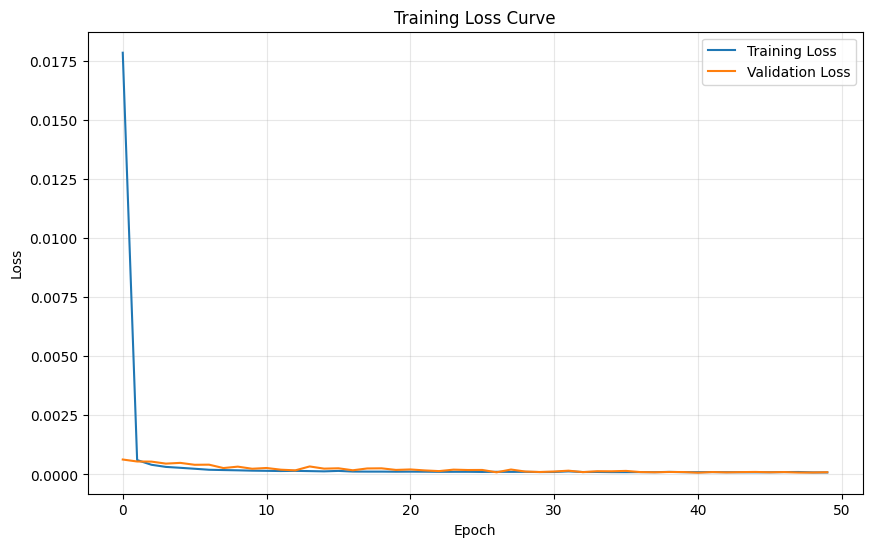

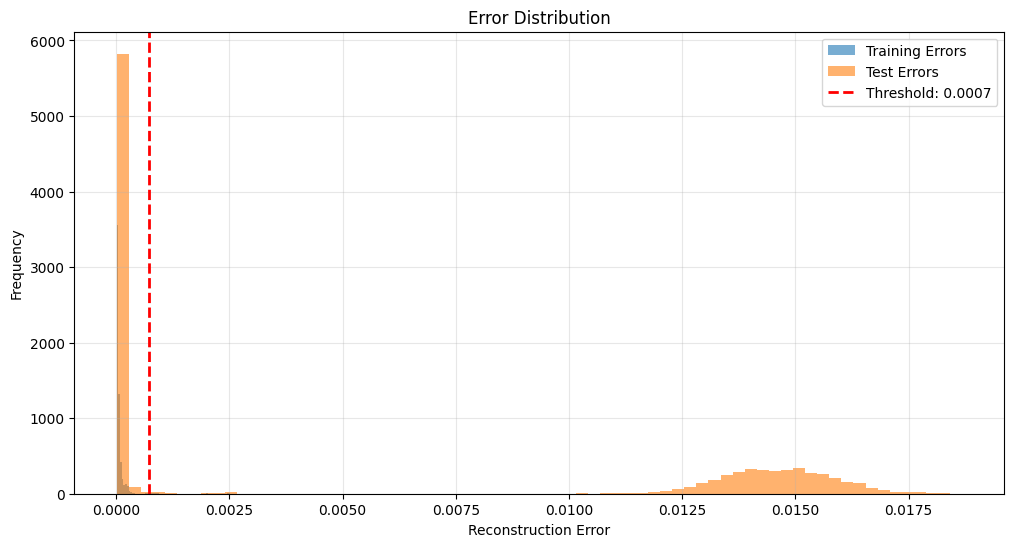

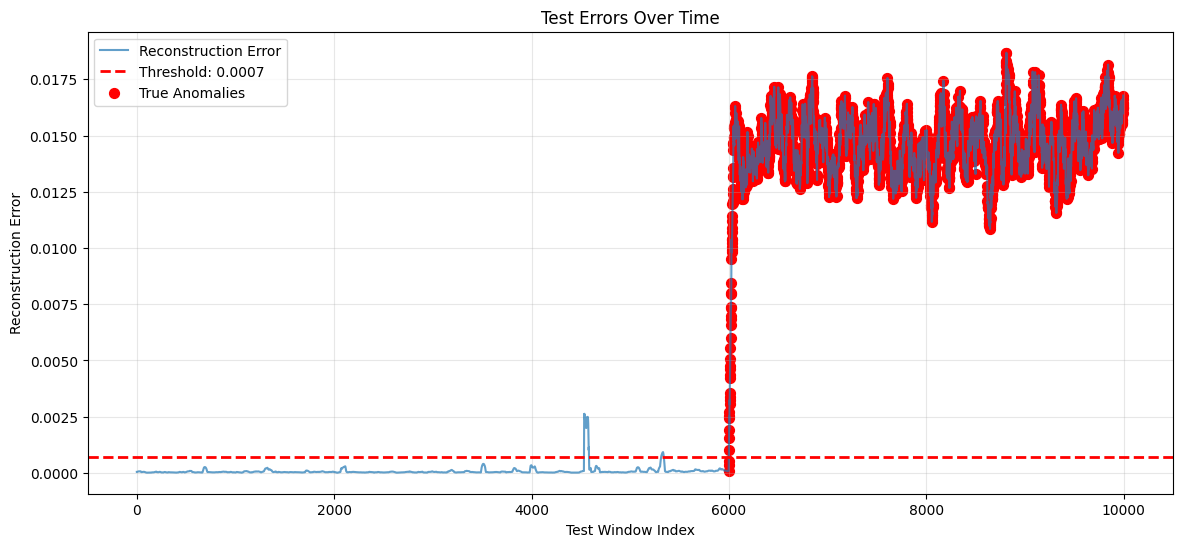

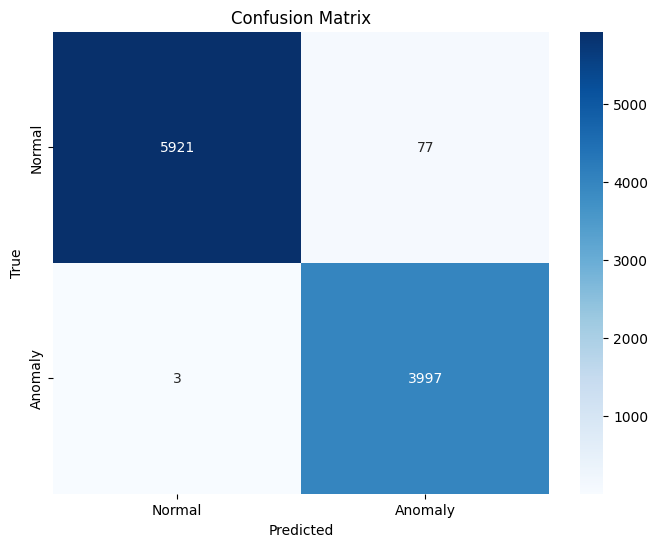

In [12]:
# STEP 11 : PLOTS

# Print step message indicating visualization stage
print("\n[STEP 11] Creating visualizations...")


# ---------------------------------------------------
# Plot 1: Training and Validation Loss Curve
# ---------------------------------------------------

# Create a new figure for the loss curve
plt.figure(figsize=(10, 6))

# Plot training loss recorded during training
plt.plot(history.history['loss'], label='Training Loss')

# Plot validation loss
plt.plot(history.history['val_loss'], label='Validation Loss')

# Label axes
plt.xlabel('Epoch')
plt.ylabel('Loss')

# Title of the plot
plt.title('Training Loss Curve')

# Display legend
plt.legend()

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Save plot as an image
plt.savefig('01_training_loss_curve.png')

# Display the plot
plt.show()



# ---------------------------------------------------
# Plot 2: Reconstruction Error Distribution
# ---------------------------------------------------

plt.figure(figsize=(12, 6))

# Histogram of training reconstruction errors
plt.hist(train_errors, bins=70, alpha=0.6, label='Training Errors')

# Histogram of test reconstruction errors
plt.hist(test_errors, bins=70, alpha=0.6, label='Test Errors')

# Draw vertical line showing anomaly detection threshold
plt.axvline(threshold, color='red', linestyle='--', linewidth=2,
            label=f'Threshold: {threshold:.4f}')

# Label axes
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')

# Plot title
plt.title('Error Distribution')

# Show legend
plt.legend()

# Add grid
plt.grid(True, alpha=0.3)

# Save image
plt.savefig('02_error_histogram.png')

# Display plot
plt.show()



# ---------------------------------------------------
# Plot 3: Reconstruction Error Over Time
# ---------------------------------------------------

plt.figure(figsize=(14, 6))

# Plot reconstruction error for each test window
plt.plot(test_errors, label='Reconstruction Error', alpha=0.7)

# Plot horizontal threshold line
plt.axhline(threshold, color='red', linestyle='--', linewidth=2,
            label=f'Threshold: {threshold:.4f}')

# Identify indices where true anomalies occur
anomaly_indices = np.where(y_windows == 1)[0]

# Highlight anomalies with red points
if len(anomaly_indices) > 0:
    plt.scatter(anomaly_indices,
                test_errors[anomaly_indices],
                color='red',
                s=50,
                label='True Anomalies')

# Label axes
plt.xlabel('Test Window Index')
plt.ylabel('Reconstruction Error')

# Title
plt.title('Test Errors Over Time')

# Show legend
plt.legend()

# Add grid
plt.grid(True, alpha=0.3)

# Save plot
plt.savefig('03_test_errors_timeline.png')

# Display plot
plt.show()



# ---------------------------------------------------
# Plot 4: Confusion Matrix Heatmap
# ---------------------------------------------------

plt.figure(figsize=(8, 6))

# Create heatmap visualization of confusion matrix
sns.heatmap(cm,
            annot=True,        # Show numbers inside cells
            fmt='d',           # Integer formatting
            cmap='Blues',      # Color scheme
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])

# Label axes
plt.xlabel('Predicted')
plt.ylabel('True')

# Plot title
plt.title('Confusion Matrix')

# Save image
plt.savefig('04_confusion_matrix.png')

# Display plot
plt.show()

## Step 12 : Save the Model and Required Objects

### Description

In this step, we save the **trained autoencoder model**, the **data scaler**, and the **anomaly detection threshold**.
Saving these allows the model to be **reused later for prediction or deployment without retraining**.

In [13]:
# STEP 12: SAVE MODEL

# Print step message
print("\n[STEP 12] Saving model and scaler...")

# Create 'models' folder if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the trained autoencoder model
model.save('models/anomaly_detector_model.h5')
print("✓ Saved: models/anomaly_detector_model.h5")

# Save the scaler used for normalization
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✓ Saved: models/scaler.pkl")

# Save anomaly detection threshold
with open('models/threshold.pkl', 'wb') as f:
    pickle.dump(threshold, f)
print("✓ Saved: models/threshold.pkl")

# Final message
print("\n" + "="*80)
print("MODEL TRAINING COMPLETE AND SAVED")
print("="*80)



[STEP 12] Saving model and scaler...
✓ Saved: models/anomaly_detector_model.h5
✓ Saved: models/scaler.pkl
✓ Saved: models/threshold.pkl

MODEL TRAINING COMPLETE AND SAVED
